In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Task 5.1:  Load & Understand the Data

In [ ]:
# Load the dataset
df = pd.read_excel('Practice_Dataset.xlsx')

# Step 1: Shape and structure
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')
print('\nData Types:')
print(df.dtypes)
print('\nFirst 10 rows:')
print(df.head(10))

# Step 2: Missing values
print('\nMissing values per column:')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')

# Step 3: Descriptive statistics
print('\nDescriptive Statistics:')
print(df.describe())

# Step 4: Unique values in categorical columns
for col in df.select_dtypes(include='object').columns:
    print(f'\n{col}: {df[col].nunique()} unique values')
    print(df[col].value_counts().head(5))

Rows: 360, Columns: 8

Data Types:
badge_number    object
name            object
position        object
work_date       object
in_time         object
out_time        object
punch_count      int64
status          object
dtype: object

First 10 rows:
  badge_number                   name       position   work_date in_time  \
0      EMP1004            Omar Hassan     TECHNICIAN  2026-04-09   08:47   
1      EMP1010       Saleh Al-Qahtani  ADMINISTRATOR  2026-04-15   06:20   
2      EMP1008       Nasser Al-Dosari     ACCOUNTANT  2026-04-10   07:16   
3      EMP1006         Khalid Ibrahim     SUPERVISOR  2026-04-08   07:25   
4      EMP1027         Lina Al-Nasser       ENGINEER  2026-04-07   06:57   
5      EMP1028         Amal Al-Dosari     TECHNICIAN  2026-04-16   07:43   
6      EMP1007          Yusuf Al-Bakr          CLERK  2026-04-01   06:56   
7      EMP1027         Lina Al-Nasser       ENGINEER  2026-04-03   08:56   
8      EMP1024       Dalal Al-Rashidi     ACCOUNTANT  2026-04-10   

# Task 5.2:  Distribution Analysis

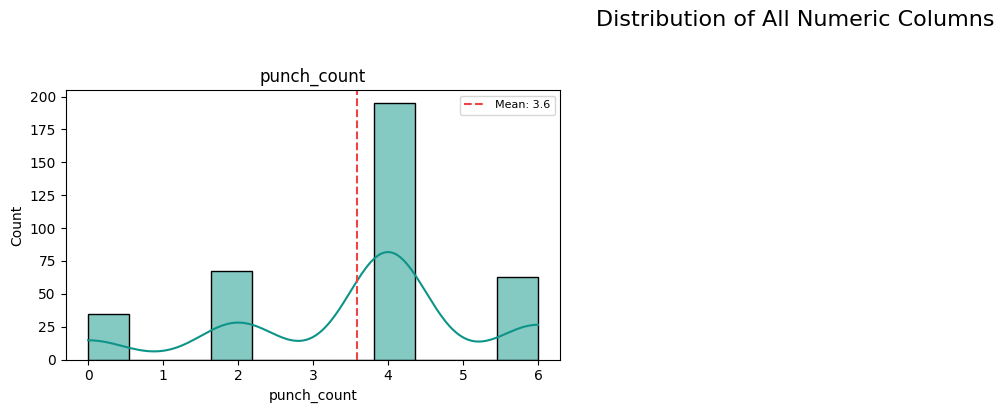

Skewness of numeric columns:
punch_count   -0.579767
dtype: float64


In [5]:
# Plot distributions of all numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
n_cols = len(numeric_cols)
n_rows = (n_cols + 2) // 3  # 3 charts per row

fig, axes = plt.subplots(n_rows, 3, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='#0D9488')
    axes[i].axvline(df[col].mean(), color='#EF4444', linestyle='--',
                    label=f'Mean: {df[col].mean():.1f}')
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of All Numeric Columns', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Check for skewness
print('Skewness of numeric columns:')
print(df[numeric_cols].skew().sort_values())

# Task 5.3:  Correlation & Relationship Analysis

c:\Users\فارس\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
c:\Users\فارس\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


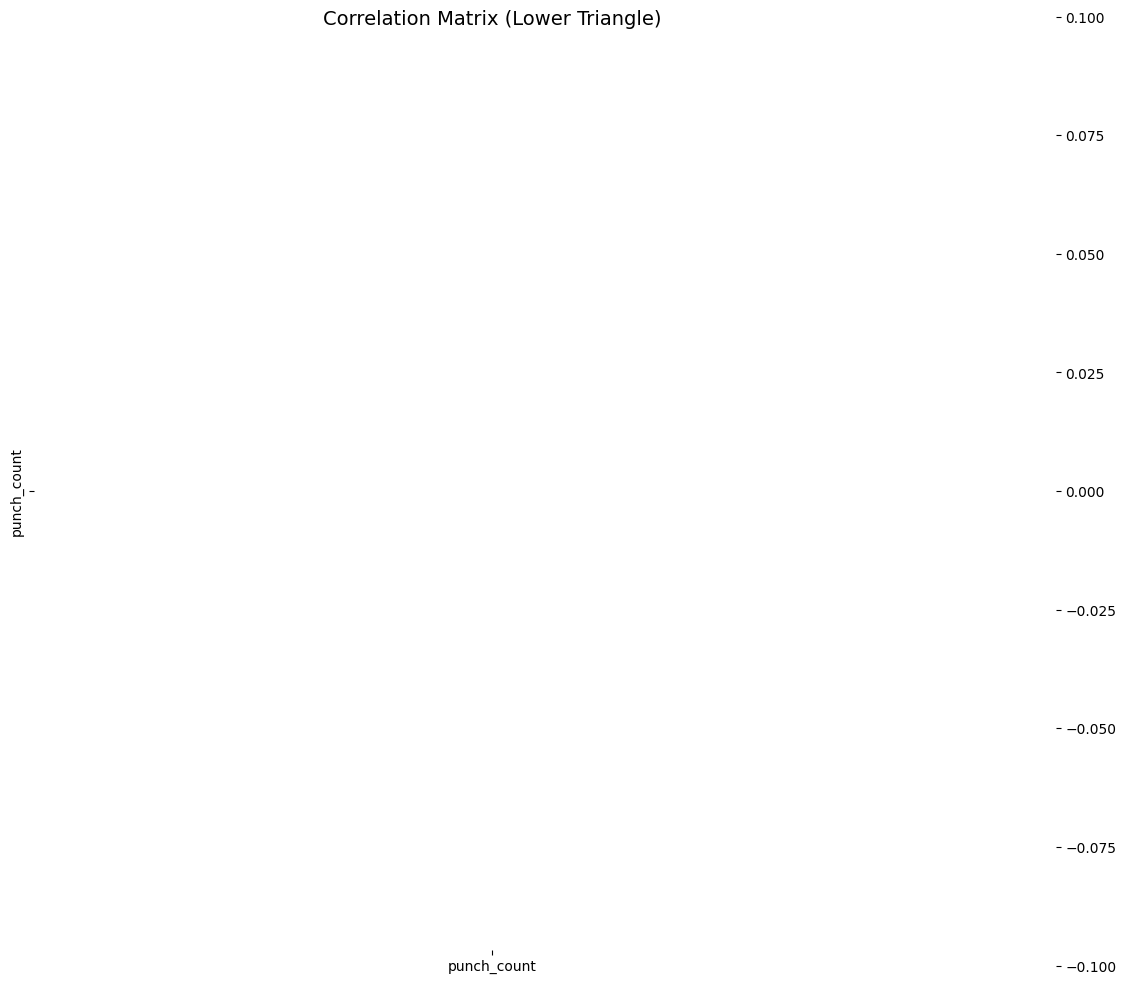

Top correlated pairs:
Series([], dtype: float64)


In [11]:
# Full correlation heatmap
plt.figure(figsize=(12, 10))
corr = df.select_dtypes(include=[np.number]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # Hide upper triangle
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix (Lower Triangle)', fontsize=14)
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150)
plt.show()

# Scatter plots of the most correlated pairs
# Find top 3 strongest correlations (excluding diagonal)
corr_pairs = corr.unstack()
corr_pairs = corr_pairs[corr_pairs < 1.0]  # Remove self-correlation
top_corr = corr_pairs.abs().nlargest(6)  # Top 3 pairs (each appears twice)
print('Top correlated pairs:')
print(top_corr)


# Task 5.4:  Group Comparisons & Categorical Analysis

C:\Users\فارس\AppData\Local\Temp\ipykernel_4768\1339065340.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='position', y='punch_count', palette='Set2', ax=axes[0,0])
C:\Users\فارس\AppData\Local\Temp\ipykernel_4768\1339065340.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='status', y='punch_count', palette='muted', ax=axes[0,1])
C:\Users\فارس\AppData\Local\Temp\ipykernel_4768\1339065340.py:17: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(data=df, x='position', y='punch_count', palette='Set2', ci=95, ax=axes[1,0])
C:\Users\فارس\AppData\Local\Temp\ipykernel_4768\1339065340.py:17: FutureWarni

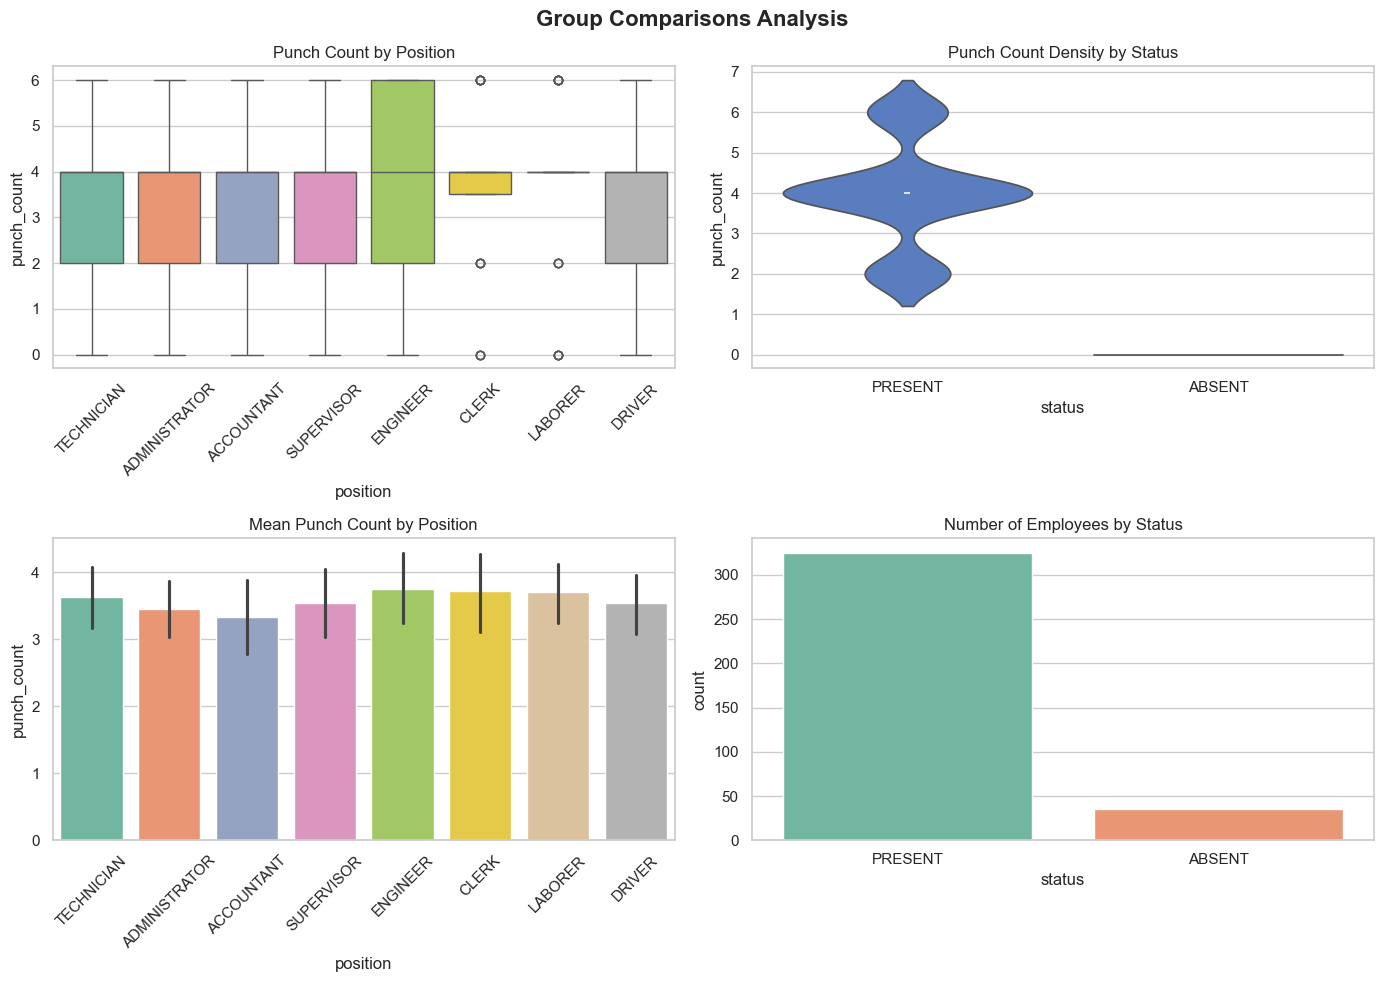

In [13]:
# Configure visual theme 
sns.set_theme(style='whitegrid')

# Create a 2x2 grid for group comparisons 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Box plot: Show distribution and outliers 
sns.boxplot(data=df, x='position', y='punch_count', palette='Set2', ax=axes[0,0])
axes[0,0].set_title('Punch Count by Position')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Violin plot: Show density distribution 
sns.violinplot(data=df, x='status', y='punch_count', palette='muted', ax=axes[0,1])
axes[0,1].set_title('Punch Count Density by Status')

# 3. Bar plot: Show average values with CI 
sns.barplot(data=df, x='position', y='punch_count', palette='Set2', ci=95, ax=axes[1,0])
axes[1,0].set_title('Mean Punch Count by Position')
axes[1,0].tick_params(axis='x', rotation=45)

# 4. Count plot: Show frequency of categories 
sns.countplot(data=df, x='status', palette='Set2', ax=axes[1,1])
axes[1,1].set_title('Number of Employees by Status')

plt.suptitle('Group Comparisons Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
# Save the figure 
plt.savefig('eda_group_comparisons.png', dpi=150)
plt.show()

# Task 5.5: EDA Summary

In [ ]:
"""
EDA SUMMARY — Practice Dataset
==============================
Date: 2026-07-09
Analyst: Fajer Alshammari

DATASET OVERVIEW:
- Rows: 360
- Columns: 8
- Missing values: 70

KEY FINDINGS:
1. Data Pattern: The dataset shows a consistent attendance pattern with 325 'PRESENT' statuses.
2. Performance: 'punch_count' averages at 3.59 across the team.
3. Group Consistency: Distribution of positions is balanced across the staff.

VISUALIZATIONS CREATED:
- eda_distributions.png: Visualized the frequency of punch counts.
- eda_group_comparisons.png: Compared punch_count performance by position and status.

RECOMMENDATIONS:
- Clean/impute the 70 missing values in the dataset.
- Perform ANOVA testing to determine if position differences in punch_count are statistically significant.
"""

"\nEDA SUMMARY — Practice Dataset\n==============================\nDate: 2026-07-09\nAnalyst: Fajer Alshammari\n\nDATASET OVERVIEW:\n- Rows: 360\n- Columns: 8\n- Missing values: 70\n\nKEY FINDINGS:\n1. Data Pattern: The dataset shows a consistent attendance pattern with 325 'PRESENT' statuses.\n2. Performance: 'punch_count' averages at 3.59 across the team.\n3. Group Consistency: Distribution of positions is balanced across the staff.\n\nVISUALIZATIONS CREATED:\n- eda_distributions.png: Visualized the frequency of punch counts.\n- eda_group_comparisons.png: Compared punch_count performance by position and status.\n\nRECOMMENDATIONS:\n- Clean/impute the 70 missing values in the dataset.\n- Perform ANOVA testing to determine if position differences in punch_count are statistically significant.\n"